**<center>M1 Seminar - 2026.4.9</center>**
**<center>_Topic_: OT(Oblivious Transfer) and OTE(Oblivious Transfer Extension)</center>**
<center>Group: Oskar Piibar, Celia Gimenez, Jianyu Liu</center>


#### List of notebook requirements:
1. Python 3
3. Numpy
4. Matplotlib
5. Hashlib
6. Secrets

#### Notebook usage:
- The notebook is interactive after executing it
- Please ignore all code section when reading this notebook. It is sufficient to look at the figures and read the markdowns.


In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import secrets
import time

In [2]:
# Helper functions

def measure_time(func, *args, **kwargs):
    """Run func(*args) and return (result, elapsed_ms)."""
    t0 = time.perf_counter()
    result = func(*args, **kwargs)
    return result, (time.perf_counter() - t0) * 1000


def H(*args) -> bytes:
    """
    Hash function (random oracle).
    Accepts ints, bytes, or numpy uint8 arrays.
    Returns 32 bytes.
    """
    h = hashlib.sha256()
    for a in args:
        if isinstance(a, int):
            h.update(a.to_bytes(8, 'big'))
        elif isinstance(a, (bytes, bytearray)):
            h.update(a)
        elif isinstance(a, np.ndarray):
            h.update(a.tobytes())   # deterministic: each uint8 element → 1 byte
    return h.digest()


def xor_bytes(a: bytes, b: bytes) -> bytes:
    """XOR two equal-length byte strings."""
    return bytes(x ^ y for x, y in zip(a, b))


def prg(seed: bytes, n_bits: int) -> np.ndarray:
    """
    Pseudorandom Generator — SHA-256 in counter mode.
    Expands `seed` (bytes) into `n_bits` pseudorandom bits (np.uint8 array).
    """
    buf = bytearray()
    ctr = 0
    while len(buf) * 8 < n_bits:
        buf += hashlib.sha256(seed + ctr.to_bytes(4, 'big')).digest()
        ctr += 1
    return np.unpackbits(np.frombuffer(bytes(buf), dtype=np.uint8))[:n_bits].astype(np.uint8)


# Secure Multiparty Computation — OT vs OT Extension
Comparing **Simple Oblivious Transfer** (DH-based) against
**IKNP OT Extension** (Ishai, Kilian, Nissim, Petrank 2003).

 

## Introduction

### Oblivious Transfer

Oblivious Transfer (OT) is a fundamental cryptographic protocol where a Sender has two messages $(M_0, M_1)$ and a Receiver chooses to receive one of them $(M_r)$. \
The protocol ensures two things:
1. Receiver Privacy: The Sender doesn't know which message the Receiver chose.
2. Sender Privacy: The Receiver only learns the chosen message and nothing about the other.

## Example problem

Bank A (the Sender) maintains a large database of $2^{13}$ (8,192) high-risk individuals on a credit blacklist. \
Bank B (the Receiver) has a potential loan applicant and wants to verify if this person is on Bank A's list without compromising privacy.\
Bank B cannot reveal the identity of its applicant to Bank A to prevent customer poaching or privacy leaks.\
Bank A cannot share its entire blacklist with Bank B to protect proprietary business data and comply with regulations.

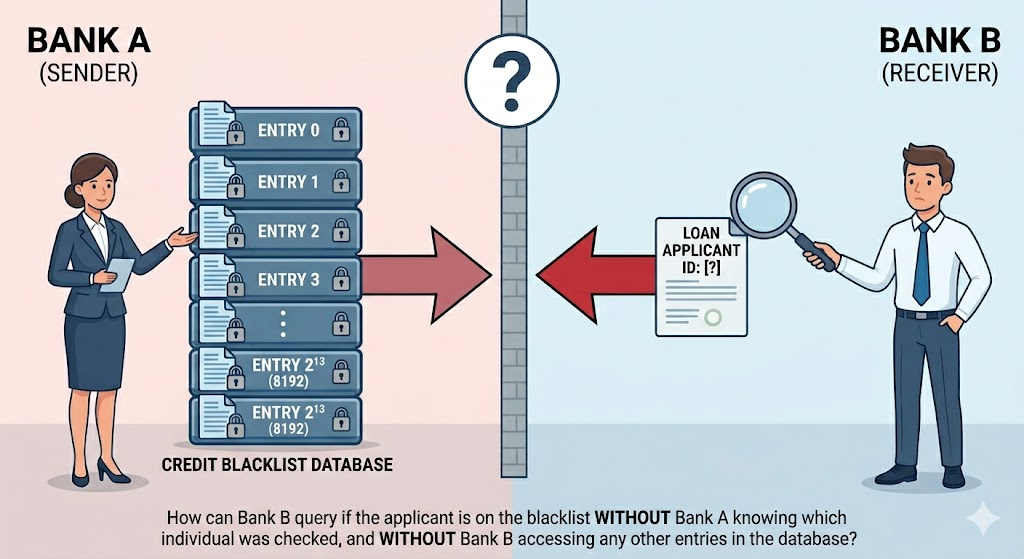

## OT Solution


── DH group ──────────────────────────────────────────────────────────────
 
Using the Mersenne prime 2^61 − 1 for fast demo arithmetic.
A production implementation would use a 2048-bit safe prime (e.g. RFC 3526).

In [3]:
DH_P = (1 << 61) - 1   # Mersenne prime, 61 bits
DH_G = 2               # generator

### **Naor-Pinkas 1-out-of-2 OT (DH-based)**

---

#### 1. Participants & Objectives 
| Role | Possession | Goal |
| :--- | :--- | :--- |
| Sender  | Messages $m_0, m_1$ | Send $m_c$ without knowing $c$ |
| Receiver  | Choice $c \in \{0, 1\}$ | Get $m_c$ without learning $m_{1-c}$ |

---

#### 2. Protocol Steps 

**Step 1: Initialization  (Sender)**
- Sender generates a random secret $a \leftarrow \mathbb{Z}_p$ and broadcasts the public key $A = g^a$.


**Step 2: Blinding  (Receiver)**
- Receiver picks a random $b \leftarrow \mathbb{Z}_p$.
- Calculates $B$ based on choice $c$:
  - If $c=0$: $B = g^b$
  - If $c=1$: $B = A \cdot g^b$
- Receiver computes decryption key: $k_{recv} = A^b = g^{ab}$.

**Step 3: Encryption  (Sender)**
- Sender receives $B$ and derives two potential keys:
  - $k_0 = B^a$
  - $k_1 = (B/A)^a$
- Sender encrypts both: $e_0 = m_0 \oplus H(k_0)$, $e_1 = m_1 \oplus H(k_1)$.

**Step 4: Recovery  (Receiver)**
- Receiver recovers the message: $m_c = e_c \oplus H(k_{recv})$.

Security: computationally secure under the DDH assumption.\
Cost:     O(1) modular exponentiations per OT  ← the expensive part.

In [ ]:


def simple_ot(m0: bytes, m1: bytes, choice: int) -> bytes:

    P, G = DH_P, DH_G

    # ── Sender setup ──────────────────────────────────────────────────────
    a = secrets.randbelow(P - 2) + 2
    A = pow(G, a, P)                        # A = g^a  [mod P]

    # ── Receiver encodes choice in public key B ───────────────────────────
    b = secrets.randbelow(P - 2) + 2
    if choice == 0:
        B = pow(G, b, P)                    # B = g^b
    else:
        B = (A * pow(G, b, P)) % P          # B = A · g^b
    k_recv = pow(A, b, P)                   # = A^b = g^(ab)

    # ── Sender builds two encryption keys ─────────────────────────────────
    k0 = pow(B, a, P)                       # k0 = B^a
    A_inv = pow(A, P - 2, P)               # A^{−1} mod P  (Fermat's little theorem)
    k1 = pow((B * A_inv) % P, a, P)        # k1 = (B/A)^a

    # ── Sender encrypts both messages ─────────────────────────────────────
    e0 = xor_bytes(m0, H(k0)[:len(m0)])
    e1 = xor_bytes(m1, H(k1)[:len(m1)])

    # ── Receiver decrypts the chosen message ──────────────────────────────
    pad = H(k_recv)[:len(m0)]
    return xor_bytes(e0 if choice == 0 else e1, pad)


# ── correctness check ─────────────────────────────────────────────────────
assert simple_ot(b"hello_m0__", b"hello_m1__", 0) == b"hello_m0__"
assert simple_ot(b"hello_m0__", b"hello_m1__", 1) == b"hello_m1__"
print("Simple OT  ✓  correctness check passed")


def bench_simple_ot(n: int) -> float:
    """Run n independent Simple OTs. Returns total wall-clock time in ms."""
    m0, m1 = secrets.token_bytes(16), secrets.token_bytes(16)
    t0 = time.perf_counter()
    for i in range(n):
        simple_ot(m0, m1, i % 2)
    return (time.perf_counter() - t0) * 1000


Simple OT  ✓  correctness check passed


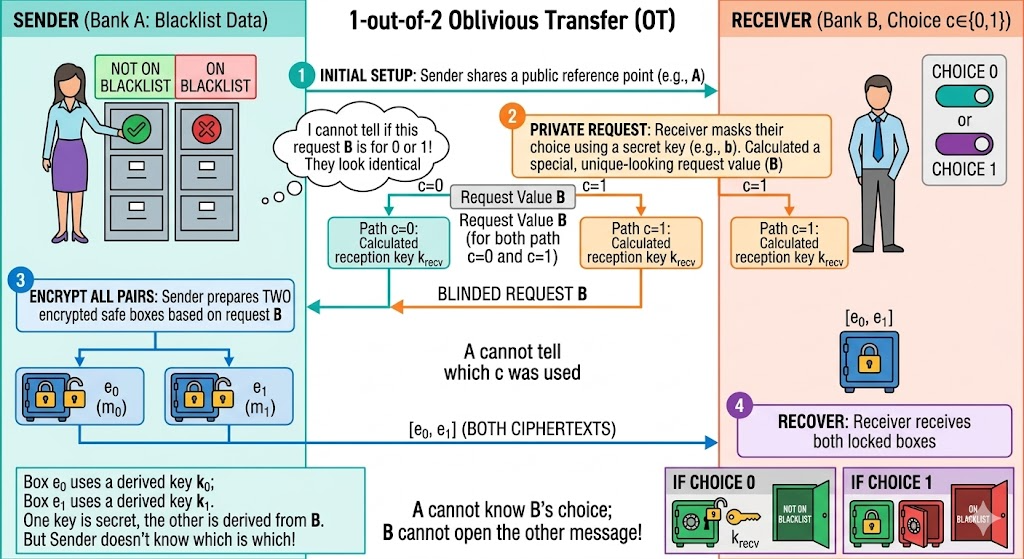

## Bottleneck

Each 1-out-of-2 OT requires multiple modular exponentiations ($g^a, g^b, B^a$, etc.). These are "heavy" asymmetric cryptographic operations. If Bank A’s database has $N=8192$ ($2^{13}$) records, performing 8192 individual OT protocols would consume massive CPU cycles and cause significant latency.\
The cost of base OT scales linearly with the number of queries. In a real-world financial system with millions of checks, $O(N)$ modular exponentiations are simply not scalable. The server would be overwhelmed by the sheer volume of complex math before a single verification is completed.

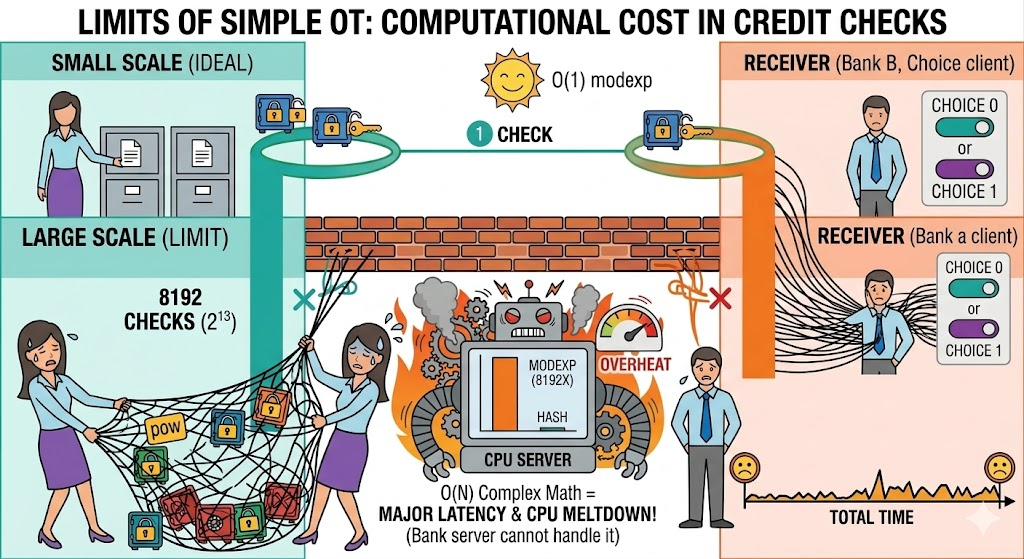

## OT Extension (IKNP Protocol)
**Objective:** Extend $k$ expensive base OTs into $m$ cheap OTs ($m \gg k$).

---

#### **Core Concept**
- **Base OTs**: Perform $k$ DH-based OTs (Fixed setup cost: $k \times \text{modexp}$).
- **Extension**: Use Symmetric Primitives (PRG, XOR, Hash) to generate $m$ OTs (Marginal cost: $m \times \text{hash}$).
- **Efficiency**: For large $m$, the amortized cost per OT approaches the cost of a single hash operation.

---

#### **Protocol Sketch**
**Notation:** - $m$: Number of messages.
- $k$: Security parameter (e.g., 128).
- $r \in \{0,1\}^m$: Receiver's choice bits.
- $s \in \{0,1\}^k$: Sender's random selection string.

**Step 1 — Setup (Sender)**
- Sender samples a random correlation string $s \in \{0,1\}^k$.

**Step 2 — Base OTs (Reversed Roles)**
- **Role Swap**: Receiver acts as OT-Sender; Sender acts as OT-Receiver with choices $s_j$.
- Receiver has pairs $(seeds_{0,j}, seeds_{1,j})$.
- Sender receives $q_j = seeds_{s_j, j}$ for $j=1 \dots k$.

**Step 3 — Matrix Construction (Receiver)**
- Receiver builds matrix $T$ ($k \times m$) and correction $U$:
  - $T_j = \text{PRG}(seeds_{0,j})$
  - $U_j = \text{PRG}(seeds_{1,j}) \oplus T_j \oplus r$
- Receiver sends $U$ to Sender.

**Step 4 — Matrix Construction (Sender)**
- Sender builds matrix $Q$:
  - $Q_j = \text{PRG}(q_j) \oplus (s_j \cdot U_j)$
  - Resulting Relationship: $Q_i = T_i \oplus (r_i \cdot s)$ (where $i$ is the column index).

**Step 5 — Efficient Transfer (Hashing)**
- **Sender computes ciphertexts**:
  - $e_{0,i} = m_{0,i} \oplus H(i, Q_i)$
  - $e_{1,i} = m_{1,i} \oplus H(i, Q_i \oplus s)$
- **Receiver recovers message**:
  - Key: $H(i, T_i)$
  - If $r_i=0$: $H(T_i) = H(Q_i) \implies$ Decrypts $e_{0,i}$
  - If $r_i=1$: $H(T_i) = H(Q_i \oplus s) \implies$ Decrypts $e_{1,i}$

---

#### **Complexity**
- **Computation**: $k$ Asymmetric Ops + $O(m)$ Symmetric Ops.
- **Amortized Cost**: $\approx O(1)$ Hash per OT.

In [ ]:


def iknp_ote(sender_m0: list,
             sender_m1: list,
             receiver_choices: np.ndarray,
             k: int = 128) -> list:

    m = len(receiver_choices)
    r = receiver_choices.astype(np.uint8)                # (m,)

    # ── Step 1: Sender samples s ∈ {0,1}^k ───────────────────────────────
    s_raw = secrets.token_bytes((k + 7) // 8)
    s = np.unpackbits(np.frombuffer(s_raw, dtype=np.uint8))[:k].astype(np.uint8)  # (k,)

    # ── Step 2: k base OTs ────────────────────────────────────────────────
    # R provides seed pairs; S picks with s[j].  Only k DH operations here.
    seeds0 = [secrets.token_bytes(16) for _ in range(k)]
    seeds1 = [secrets.token_bytes(16) for _ in range(k)]
    q_keys = [simple_ot(seeds0[j], seeds1[j], int(s[j])) for j in range(k)]

    # ── Step 3: R builds T (k×m) and correction U ─────────────────────────
    T = np.array([prg(seeds0[j], m) for j in range(k)], dtype=np.uint8)   # (k, m)
    U = np.array(
        [prg(seeds1[j], m) ^ T[j] ^ r for j in range(k)], dtype=np.uint8
    )                                                                       # (k, m)

    # ── Step 4: S builds Q (k×m) ─────────────────────────────────────────
    Q = np.array(
        [prg(q_keys[j], m) ^ (s[j] * U[j]) for j in range(k)], dtype=np.uint8
    )                                                                       # (k, m)

    # ── Step 5: Transfer m messages using hashing ─────────────────────────
    Qt = Q.T   # (m, k): Qt[i] = i-th row of Q  =  Q_i
    Tt = T.T   # (m, k): Tt[i] = i-th row of T  =  T_i

    results = []
    for i in range(m):
        key0 = H(i, Qt[i])
        key1 = H(i, (Qt[i] ^ s).astype(np.uint8))

        e0 = xor_bytes(sender_m0[i], key0[:len(sender_m0[i])])
        e1 = xor_bytes(sender_m1[i], key1[:len(sender_m1[i])])

        recv_key = H(i, Tt[i])
        chosen   = e0 if r[i] == 0 else e1
        results.append(xor_bytes(chosen, recv_key[:len(sender_m0[i])]))

    return results


# ── correctness check (k=16 for speed) ───────────────────────────────────
_m0 = [b"msg_0_" + bytes([i]) for i in range(20)]
_m1 = [b"msg_1_" + bytes([i]) for i in range(20)]
_ch = np.array([i % 2 for i in range(20)], dtype=np.uint8)
_res = iknp_ote(_m0, _m1, _ch, k=16)
for i in range(20):
    assert _res[i] == (_m0[i] if _ch[i] == 0 else _m1[i])
print("IKNP OTE   ✓  correctness check passed")


def bench_iknp_ote(n: int, k: int = 128) -> float:
    """Run IKNP OTE for n messages. Returns total wall-clock time in ms."""
    m0 = [secrets.token_bytes(16)] * n
    m1 = [secrets.token_bytes(16)] * n
    choices = np.array([i % 2 for i in range(n)], dtype=np.uint8)
    t0 = time.perf_counter()
    iknp_ote(m0, m1, choices, k=k)
    return (time.perf_counter() - t0) * 1000


IKNP OTE   ✓  correctness check passed



Benchmarking Simple OT  (averaged over 5 runs)…
  n =     1        0.11 ± 0.02 ms
  n =     2        0.18 ± 0.02 ms
  n =     4        0.35 ± 0.02 ms
  n =     8        0.87 ± 0.26 ms
  n =    16        1.45 ± 0.11 ms
  n =    32        2.93 ± 0.27 ms
  n =    64        6.00 ± 0.78 ms
  n =   128       11.12 ± 0.26 ms
  n =   256       23.17 ± 0.62 ms
  n =   512       46.31 ± 1.29 ms
  n =  1024       94.61 ± 3.03 ms
  n =  2048      184.40 ± 2.41 ms
  n =  4096      368.34 ± 7.93 ms
  n =  8192      735.17 ± 7.69 ms

Benchmarking IKNP OTE  k=128  (averaged over 5 runs)…
  n =     1       16.23 ± 0.73 ms
  n =     2       14.89 ± 0.44 ms
  n =     4       15.92 ± 1.17 ms
  n =     8       16.11 ± 0.80 ms
  n =    16       15.78 ± 0.57 ms
  n =    32       18.10 ± 1.35 ms
  n =    64       17.04 ± 0.23 ms
  n =   128       19.12 ± 0.49 ms
  n =   256       24.01 ± 1.81 ms
  n =   512       33.54 ± 2.00 ms
  n =  1024       48.79 ± 1.05 ms
  n =  2048       84.82 ± 3.88 ms
  n =  4096 

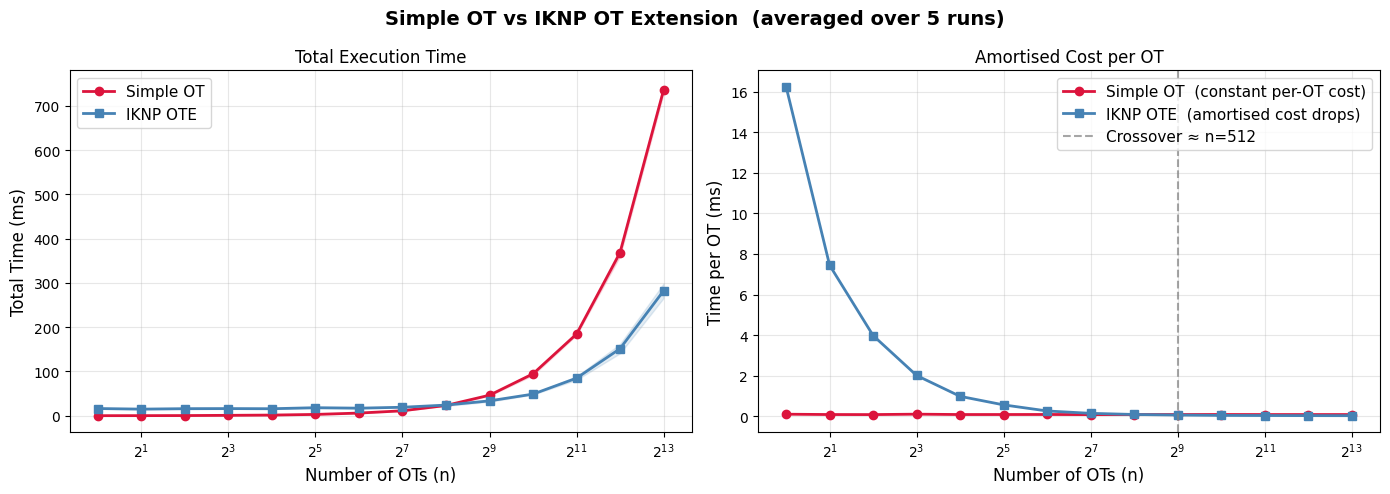


══════════════════════════════════════════════════
  Summary at n = 8192 OTs
══════════════════════════════════════════════════
  Simple OT :  0.0897 ms / OT
  IKNP OTE  :  0.0344 ms / OT
  Speedup   :  2.6×
  Crossover :  n ≈ 512  (IKNP wins beyond this point)


In [6]:
# Plot the graphs

# Extended n range — goes well past the IKNP crossover point (~k=128)
N_VALUES = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]

# Number of repetitions to average over — smooths out OS/cache noise
REPS = 5


def bench_avg(bench_fn, n, reps=REPS, **kwargs) -> tuple[float, float]:
    """
    Run bench_fn(n) `reps` times and return (mean_ms, std_ms).
    Averaging eliminates the OS scheduling noise that caused the
    IKNP curve to look jagged at small n.
    """
    times = [bench_fn(n, **kwargs) for _ in range(reps)]
    return float(np.mean(times)), float(np.std(times))


print(f"\nBenchmarking Simple OT  (averaged over {REPS} runs)…")
simple_mean, simple_std = [], []
for n in N_VALUES:
    mean, std = bench_avg(bench_simple_ot, n)
    simple_mean.append(mean)
    simple_std.append(std)
    print(f"  n = {n:5d}   {mean:9.2f} ± {std:.2f} ms")

print(f"\nBenchmarking IKNP OTE  k=128  (averaged over {REPS} runs)…")
iknp_mean, iknp_std = [], []
for n in N_VALUES:
    mean, std = bench_avg(bench_iknp_ote, n, k=128)
    iknp_mean.append(mean)
    iknp_std.append(std)
    print(f"  n = {n:5d}   {mean:9.2f} ± {std:.2f} ms")

# ── amortised per-OT cost ─────────────────────────────────────────────────
simple_per_ot = [m / n for m, n in zip(simple_mean, N_VALUES)]
iknp_per_ot   = [m / n for m, n in zip(iknp_mean,  N_VALUES)]

# ── plot ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Simple OT vs IKNP OT Extension  (averaged over {REPS} runs)",
    fontsize=14, fontweight='bold'
)

# Left — total time with shaded ±1 std band
ax1.plot(N_VALUES, simple_mean, 'o-', color='crimson',   lw=2, label='Simple OT')
ax1.fill_between(N_VALUES,
                 [m - s for m, s in zip(simple_mean, simple_std)],
                 [m + s for m, s in zip(simple_mean, simple_std)],
                 color='crimson', alpha=0.15)

ax1.plot(N_VALUES, iknp_mean, 's-', color='steelblue', lw=2, label='IKNP OTE')
ax1.fill_between(N_VALUES,
                 [m - s for m, s in zip(iknp_mean, iknp_std)],
                 [m + s for m, s in zip(iknp_mean, iknp_std)],
                 color='steelblue', alpha=0.15)

ax1.set_xscale('log', base=2)
ax1.set_xlabel('Number of OTs (n)', fontsize=12)
ax1.set_ylabel('Total Time (ms)',   fontsize=12)
ax1.set_title('Total Execution Time')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right — amortised cost per OT
ax2.plot(N_VALUES, simple_per_ot, 'o-', color='crimson',
         lw=2, label='Simple OT  (constant per-OT cost)')
ax2.plot(N_VALUES, iknp_per_ot,   's-', color='steelblue',
         lw=2, label='IKNP OTE  (amortised cost drops)')

# Mark the crossover point
crossover_n = None
for i in range(len(N_VALUES) - 1):
    if iknp_per_ot[i] > simple_per_ot[i] and iknp_per_ot[i+1] <= simple_per_ot[i+1]:
        crossover_n = N_VALUES[i+1]
        ax2.axvline(crossover_n, color='gray', lw=1.5, ls='--', alpha=0.7,
                    label=f'Crossover ≈ n={crossover_n}')
        break

ax2.set_xscale('log', base=2)
ax2.set_xlabel('Number of OTs (n)', fontsize=12)
ax2.set_ylabel('Time per OT (ms)',   fontsize=12)
ax2.set_title('Amortised Cost per OT')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ot_vs_ote.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'═'*50}")
print(f"  Summary at n = {N_VALUES[-1]} OTs")
print(f"{'═'*50}")
print(f"  Simple OT :  {simple_per_ot[-1]:.4f} ms / OT")
print(f"  IKNP OTE  :  {iknp_per_ot[-1]:.4f} ms / OT")
print(f"  Speedup   :  {simple_per_ot[-1] / iknp_per_ot[-1]:.1f}×")
if crossover_n:
    print(f"  Crossover :  n ≈ {crossover_n}  (IKNP wins beyond this point)")